# 06 — Analiza błędów: klasyczny vs HerBERT

Per-emocja P/R/F1 i FP/FN; nakładanie się błędów obu modeli; korelacja błędów z długością tekstu, liczbą etykiet i rzadkością klasy. Zbiór: TwitterEmo test.

In [ ]:
import pickle, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from thesis_lib import optimal_thresholds as opt_thresholds
warnings.filterwarnings("ignore"); sns.set_theme(style="whitegrid")
plt.rcParams["savefig.dpi"]=300

EMOTIONS=["radość","smutek","zaufanie","wstręt","strach","gniew","przeczuwanie","zdziwienie"]
RANDOM_STATE=42
PROCESSED_DIR=Path("../data/processed"); CACHE_DIR=Path("../data/features")
RESULTS_DIR=Path("../data/results"); FIGURES_DIR=Path("../figures")
CKPT=Path("../data/transformers/herbert-base-cased/checkpoint-14344")
device="cuda" if torch.cuda.is_available() else "cpu"

tw_train=pd.read_csv(PROCESSED_DIR/"twitteremo_train.csv").reset_index(drop=True)
tw_val=pd.read_csv(PROCESSED_DIR/"twitteremo_val.csv").reset_index(drop=True)
tw_test=pd.read_csv(PROCESSED_DIR/"twitteremo_test.csv").reset_index(drop=True)
for d in (tw_train,tw_val,tw_test): d["tekst"]=d["tekst"].fillna("")
y_train,y_val,y_test=(d[EMOTIONS].values for d in (tw_train,tw_val,tw_test))
print(f"test n={len(tw_test)}, device={device}")

In [3]:
# --- Klasyczny: LogReg + TF-IDF char, progi na val ---
TW=pickle.load(open(CACHE_DIR/"TW_FEATURES.pkl","rb"))
Xc=TW["tfidf_char"]
clf=OneVsRestClassifier(LogisticRegression(max_iter=1000,C=1.0,class_weight="balanced",
        solver="liblinear",random_state=RANDOM_STATE))
clf.fit(Xc["train"],y_train)
pc_val=clf.predict_proba(Xc["val"]); pc_test=clf.predict_proba(Xc["test"])
thr_c=opt_thresholds(y_val,pc_val)
pred_c=(pc_test>=thr_c).astype(int)
print("classical F1-macro:",round(f1_score(y_test,pred_c,average='macro',zero_division=0),3))

classical F1-macro: 0.474


In [4]:
# --- HerBERT-base: predykcje z checkpointu ---
tok=AutoTokenizer.from_pretrained(CKPT)
model=AutoModelForSequenceClassification.from_pretrained(CKPT).to(device).eval()

@torch.no_grad()
def predict(texts, bs=64):
    out=[]
    for i in range(0,len(texts),bs):
        enc=tok(list(texts[i:i+bs]),truncation=True,max_length=128,padding=True,return_tensors="pt").to(device)
        out.append(expit(model(**enc).logits.float().cpu().numpy()))
    return np.vstack(out)

ph_val=predict(tw_val["tekst"].tolist()); ph_test=predict(tw_test["tekst"].tolist())
thr_h=opt_thresholds(y_val,ph_val)
pred_h=(ph_test>=thr_h).astype(int)
print("HerBERT F1-macro:",round(f1_score(y_test,pred_h,average='macro',zero_division=0),3))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:  18%|█▊        | 36/201 [00:00<00:00, 341.46it/s]

Loading weights:  35%|███▌      | 71/201 [00:00<00:00, 216.25it/s]

Loading weights:  48%|████▊     | 97/201 [00:00<00:00, 213.99it/s]

Loading weights:  60%|█████▉    | 120/201 [00:00<00:00, 218.06it/s]

Loading weights:  71%|███████   | 143/201 [00:00<00:00, 181.74it/s]

Loading weights:  84%|████████▎ | 168/201 [00:00<00:00, 193.30it/s]

Loading weights:  94%|█████████▍| 189/201 [00:00<00:00, 169.42it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 204.10it/s]

HerBERT F1-macro: 0.55


## PB-A: Per-emocja — gdzie leży trudność

In [5]:
rows=[]
for i,e in enumerate(EMOTIONS):
    rows.append({"emocja":e,"support":int(y_test[:,i].sum()),
        "P_clf":precision_score(y_test[:,i],pred_c[:,i],zero_division=0),
        "R_clf":recall_score(y_test[:,i],pred_c[:,i],zero_division=0),
        "F1_clf":f1_score(y_test[:,i],pred_c[:,i],zero_division=0),
        "P_herbert":precision_score(y_test[:,i],pred_h[:,i],zero_division=0),
        "R_herbert":recall_score(y_test[:,i],pred_h[:,i],zero_division=0),
        "F1_herbert":f1_score(y_test[:,i],pred_h[:,i],zero_division=0),
        "FP_herbert":int(((pred_h[:,i]==1)&(y_test[:,i]==0)).sum()),
        "FN_herbert":int(((pred_h[:,i]==0)&(y_test[:,i]==1)).sum())})
perr=pd.DataFrame(rows).sort_values("support")
perr["F1_lift"]=(perr["F1_herbert"]-perr["F1_clf"]).round(3)
perr.to_csv(RESULTS_DIR/"err_per_emotion.csv",index=False)
display(perr.round(3))
print("Korelacja support vs F1_herbert:",round(np.corrcoef(perr['support'],perr['F1_herbert'])[0,1],3))

,emocja,support,P_clf,R_clf,F1_clf,P_herbert,R_herbert,F1_herbert,FP_herbert,FN_herbert,F1_lift
4,strach,13,0.385,0.385,0.385,0.400,0.308,0.348,6,9,-0.037
2,zaufanie,64,0.257,0.281,0.269,0.308,0.375,0.338,54,40,0.069
1,smutek,67,0.347,0.388,0.366,0.593,0.522,0.556,24,32,0.189
7,zdziwienie,93,0.285,0.398,0.332,0.491,0.559,0.523,54,41,0.191
0,radość,164,0.607,0.555,0.580,0.590,0.677,0.631,77,53,0.051
5,gniew,253,0.525,0.656,0.583,0.593,0.644,0.617,112,90,0.034
3,wstręt,333,0.547,0.685,0.608,0.660,0.694,0.676,119,102,0.068
6,przeczuwanie,504,0.581,0.786,0.668,0.662,0.776,0.714,200,113,0.046


Korelacja support vs F1_herbert: 0.822


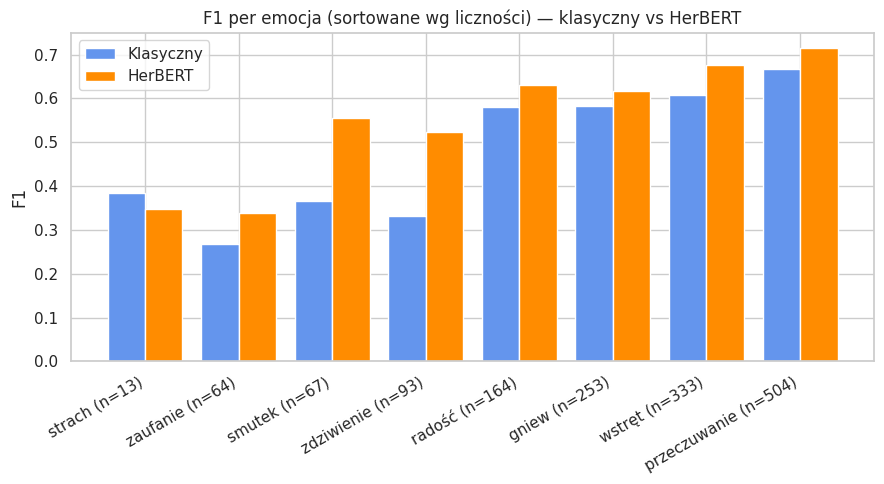

In [6]:
fig,ax=plt.subplots(figsize=(9,5))
x=np.arange(len(EMOTIONS)); w=0.4
o=perr.sort_values('support')
ax.bar(x-w/2,o['F1_clf'],w,label='Klasyczny',color='cornflowerblue')
ax.bar(x+w/2,o['F1_herbert'],w,label='HerBERT',color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(o['emocja']+' (n='+o['support'].astype(str)+')',rotation=30,ha='right')
ax.set_ylabel('F1'); ax.set_title('F1 per emocja (sortowane wg liczności) — klasyczny vs HerBERT'); ax.legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR/'err_per_emotion.pdf',bbox_inches='tight'); plt.show()

## PB-A: Przykłady błędów HerBERT (FP / FN) per emocja

In [7]:
def examples(emo_idx, kind, n=3):
    if kind=="FP": mask=(pred_h[:,emo_idx]==1)&(y_test[:,emo_idx]==0)
    else: mask=(pred_h[:,emo_idx]==0)&(y_test[:,emo_idx]==1)
    idxs=np.where(mask)[0][:n]
    for j in idxs:
        true=[EMOTIONS[k] for k in range(len(EMOTIONS)) if y_test[j,k]]
        prd=[EMOTIONS[k] for k in range(len(EMOTIONS)) if pred_h[j,k]]
        print(f"  [{kind}] «{tw_test['tekst'].iloc[j][:120]}»")
        print(f"        prawda={true} | pred={prd}")

for e in ["strach","zaufanie","smutek"]:
    i=EMOTIONS.index(e)
    print(f"=== {e} ===")
    examples(i,"FN"); examples(i,"FP")
    print()

=== strach ===
  [FN] «Boże boże a on po angielsku będzie mówić a ja go nie rozumiem xd»
        prawda=['smutek', 'strach', 'przeczuwanie'] | pred=['zdziwienie']
  [FN] «@anonymized_account Dziękuję   Oby tylko efekty były z goła inne niż te po rządach ów towarzysza»
        prawda=['strach', 'przeczuwanie'] | pred=['wstręt', 'przeczuwanie']
  [FN] «@anonymized_account @anonymized_account Ekonomia PiS zmierza do tego, że ludzie nie będą w stanie się wyżywić z jednej p»
        prawda=['smutek', 'strach', 'przeczuwanie'] | pred=['wstręt', 'gniew', 'przeczuwanie']
  [FP] «@anonymized_account Człowieku zejdź na ziemię, bo straszne odleciałeś   »
        prawda=['wstręt'] | pred=['wstręt', 'strach', 'zdziwienie']
  [FP] «tak mi się nie chce ale muszę wziąć się za lekcje»
        prawda=['smutek'] | pred=['smutek', 'strach']
  [FP] «@anonymized_account Już zaczynają pośrednio grozić krajom bałtyckim. Bandycka szajka.»
        prawda=['wstręt', 'gniew', 'przeczuwanie'] | pred=['wstręt', 'st

## PB-B: Klasyczny vs transformer — kto naprawia czyje błędy

In [8]:
# poprawność na poziomie przykładu: dokładne dopasowanie wektora etykiet
exact_c=(pred_c==y_test).all(1); exact_h=(pred_h==y_test).all(1)
# per-label trafienia
correct_c=(pred_c==y_test); correct_h=(pred_h==y_test)
both_wrong=(~correct_c)&(~correct_h)
herbert_fixes=(~correct_c)&(correct_h)
clf_only=(correct_c)&(~correct_h)
print(f"Subset-accuracy: klasyczny={exact_c.mean():.3f}  HerBERT={exact_h.mean():.3f}")
print(f"Decyzje per-label (n={y_test.size}):")
print(f"  oba dobrze:        {((correct_c)&(correct_h)).sum():6d} ({((correct_c)&(correct_h)).mean():.1%})")
print(f"  HerBERT naprawia:  {herbert_fixes.sum():6d} ({herbert_fixes.mean():.1%})")
print(f"  klasyczny lepszy:  {clf_only.sum():6d} ({clf_only.mean():.1%})")
print(f"  oba źle:           {both_wrong.sum():6d} ({both_wrong.mean():.1%})")
# w których emocjach HerBERT najwięcej naprawia
fix_by_emo=pd.DataFrame({"emocja":EMOTIONS,
    "herbert_naprawia":herbert_fixes.sum(0),"klasyczny_lepszy":clf_only.sum(0),
    "oba_zle":both_wrong.sum(0)}).sort_values("herbert_naprawia",ascending=False)
fix_by_emo.to_csv(RESULTS_DIR/"err_fixes_by_emotion.csv",index=False)
display(fix_by_emo)

Subset-accuracy: klasyczny=0.385  HerBERT=0.475
Decyzje per-label (n=11480):
  oba dobrze:          9588 (83.5%)
  HerBERT naprawia:     766 (6.7%)
  klasyczny lepszy:     483 (4.2%)
  oba źle:              643 (5.6%)


,emocja,herbert_naprawia,klasyczny_lepszy,oba_zle
6,przeczuwanie,200,120,193
3,wstręt,164,91,130
5,gniew,123,88,114
7,zdziwienie,99,45,50
0,radość,68,66,64
2,zaufanie,54,50,44
1,smutek,49,15,41
4,strach,9,8,7


## PB-C: Błędy a długość tekstu i liczba etykiet

In [9]:
n_labels=y_test.sum(1); n_words=tw_test['tekst'].str.split().str.len().values
err_per_ex_h=(pred_h!=y_test).sum(1)  # liczba błędnych etykiet na przykład
df=pd.DataFrame({"n_labels":n_labels,"n_words":n_words,"errors_herbert":err_per_ex_h,
                 "errors_clf":(pred_c!=y_test).sum(1)})
g=df.groupby("n_labels")[["errors_herbert","errors_clf"]].mean().round(3)
print("Średnia liczba błędnych etykiet wg liczby PRAWDZIWYCH emocji:"); display(g)
# binowanie długości
df["len_bin"]=pd.cut(df["n_words"],[0,10,20,30,1000],labels=["≤10","11-20","21-30",">30"])
gl=df.groupby("len_bin")[["errors_herbert","errors_clf"]].mean().round(3)
print("Średnia liczba błędnych etykiet wg długości tekstu:"); display(gl)

Średnia liczba błędnych etykiet wg liczby PRAWDZIWYCH emocji:


,errors_herbert,errors_clf
n_labels,,
0,0.346,0.491
1,0.815,1.046
2,1.254,1.488
3,1.112,1.247
4,1.333,1.667


Średnia liczba błędnych etykiet wg długości tekstu:


,errors_herbert,errors_clf
len_bin,,
≤10,0.592,0.745
11-20,0.776,0.922
21-30,1.023,1.174
>30,0.857,1.245
